In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 05 — CHOROPLETH MAPS AND LISA SPATIAL ANALYSIS
# The Gluten-Free Gap: Spatial Inequalities in NHS Prescribing and
# Retail Accessibility Across England
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
import matplotlib.cm as cm
from sklearn.metrics.pairwise import euclidean_distances
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'normal',
})

BLUE   = '#2a78d6'
GREEN  = '#1baf7a'
PURPLE = '#4a3aa7'
RED    = '#e34948'
AMBER  = '#eda100'
GREY   = '#73726c'

FIG_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures'
TAB_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\tables'

# ── Load analytical dataset ───────────────────────────────────────────────
df = pd.read_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv')

# ── Load boundary file ────────────────────────────────────────────────────
gdf = gpd.read_file(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\raw\sub_icb_boundaries_apr2026.geojson')

print(f"Analytical dataset: {df.shape}")
print(f"Boundary file: {gdf.shape}")
print(f"\nBoundary columns: {gdf.columns.tolist()}")
print(f"\nBoundary CRS: {gdf.crs}")
print(f"\nSample boundary rows:")
print(gdf.head(3))

Analytical dataset: (106, 29)
Boundary file: (106, 11)

Boundary columns: ['FID', 'SICBL26CD', 'SICBL26NM', 'ICB26CD', 'ICB26NM', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID', 'geometry']

Boundary CRS: EPSG:4326

Sample boundary rows:
   FID  SICBL26CD                                     SICBL26NM    ICB26CD  \
0    1  E38000006                 NHS South Yorkshire ICB - 02P  E54000061   
1    2  E38000007                           NHS Essex ICB - 99E  E54000066   
2    3  E38000008  NHS Nottingham and Nottinghamshire ICB - 02Q  E54000060   

                                             ICB26NM   BNG_E   BNG_N  \
0          NHS South Yorkshire Integrated Care Board  429979  403330   
1                    NHS Essex Integrated Care Board  564014  194421   
2  NHS Nottingham and Nottinghamshire Integrated ...  468073  384833   

       LONG       LAT                              GlobalID  \
0 -1.549258  53.52580  83cad37c-a2c5-4609-8d94-ebf8fa02dbde   
1  0.368068  51.62471  0ec7fbda-1454-

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2 — JOIN BOUNDARY FILE TO ANALYTICAL DATASET
# ═══════════════════════════════════════════════════════════════════════════

# Load lookup to bridge E-codes to CCG codes
lookup = pd.read_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\raw\lsoa_to_sicbl_lookup.csv'
)
code_bridge = lookup[['SICBL26CD', 'SICBL26CDH']].drop_duplicates()
code_bridge.columns = ['SICBL26CD', 'org_id']

# Join bridge to boundary file
gdf = gdf.merge(code_bridge, on='SICBL26CD', how='left')

print(f"Boundary file after bridge join: {gdf.shape}")
print(f"Unmatched boundaries: {gdf['org_id'].isna().sum()}")

# Join analytical data to boundary file
gdf = gdf.merge(df, on='org_id', how='left')

print(f"Boundary file after analytical join: {gdf.shape}")
print(f"Unmatched after analytical join: {gdf['prescribing_rate_recent'].isna().sum()}")

# Add Ball Mapper node assignment
# Rebuild BM partition at eps=1.5
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

def ball_mapper(X, epsilon):
    n    = X.shape[0]
    dist = euclidean_distances(X)
    covered = np.zeros(n, dtype=bool)
    nodes   = {}
    nid     = 0
    for i in range(n):
        if not covered[i]:
            members = np.where(dist[i] <= epsilon)[0].tolist()
            nodes[nid] = members
            for j in members:
                covered[j] = True
            nid += 1
    edges = []
    ids   = list(nodes.keys())
    for a in range(len(ids)):
        for b in range(a + 1, len(ids)):
            if set(nodes[ids[a]]) & set(nodes[ids[b]]):
                edges.append((ids[a], ids[b]))
    return nodes, edges

variables = ['prescribing_rate_recent',
             'retail_accessibility_score',
             'imd_score_weighted']
X_raw    = df[variables].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

nodes_bm, _ = ball_mapper(X_scaled, 1.5)

# Primary node assignment
primary_node = np.full(len(df), -1)
for nid, members in nodes_bm.items():
    for m in members:
        if primary_node[m] == -1:
            primary_node[m] = nid

df['bm_node'] = primary_node

node_labels = {
    0:  'N0: Consistent prescribers',
    1:  'N1: High provision, high deprivation',
    2:  'N2: Deprived withdrawers',
    3:  'N3: Extreme outlier',
    4:  'N4: Widespread low provision (deprived)',
    5:  'N5: Widespread low provision (less deprived)',
    6:  'N6: Double provision outlier',
    7:  'N7: Affluent retail-only',
    8:  'N8: Deprived NHS-dependent',
    9:  'N9: Highest prescribers',
    10: 'N10: Structural double disadvantage',
    11: 'N11: Moderate provision, least deprived',
}
df['bm_label'] = df['bm_node'].map(node_labels)

# Rejoin with BM node
gdf = gdf.merge(df[['org_id', 'bm_node', 'bm_label']],
                on='org_id', how='left')

print(f"\nFinal GeoDataFrame: {gdf.shape}")
print(f"BM node assigned: {gdf['bm_node'].notna().sum()} / {len(gdf)}")
print(f"\nCRS: {gdf.crs}")
print("Ready for choropleth mapping.")

Boundary file after bridge join: (106, 12)
Unmatched boundaries: 0
Boundary file after analytical join: (106, 40)
Unmatched after analytical join: 0

Final GeoDataFrame: (106, 42)
BM node assigned: 106 / 106

CRS: EPSG:4326
Ready for choropleth mapping.


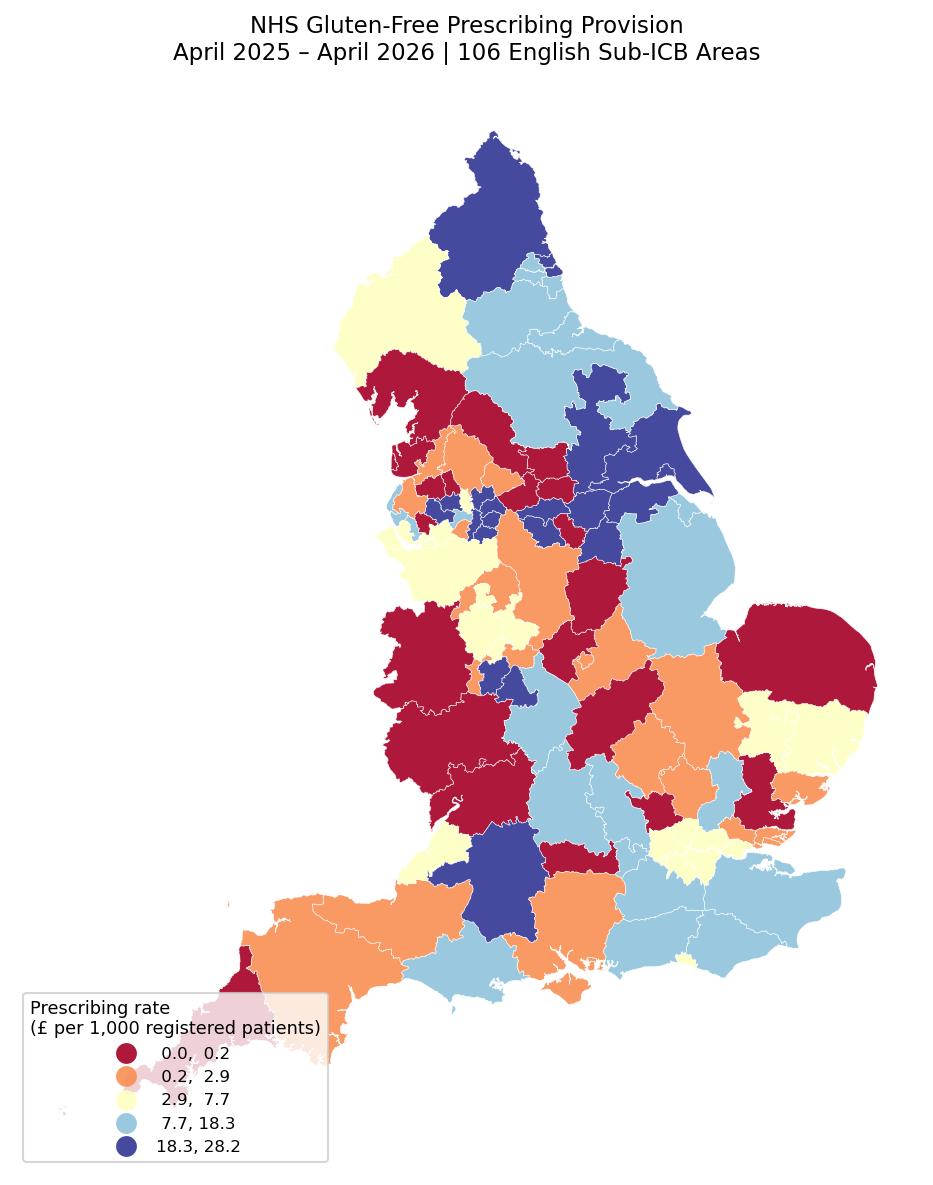

Saved MAP_01a.


In [4]:
# ── MAP 1 — NHS GF Prescribing Rate ───────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf.plot(column='prescribing_rate_recent', ax=ax,
         cmap='RdYlBu', scheme='quantiles', k=5,
         legend=True,
         legend_kwds={
             'title': 'Prescribing rate\n(£ per 1,000 registered patients)',
             'loc': 'lower left', 'fontsize': 8, 'title_fontsize': 8.5,
             'fmt': '{:.1f}',
         },
         edgecolor='white', linewidth=0.3, alpha=0.9)

ax.set_title('NHS Gluten-Free Prescribing Provision\n'
             'April 2025 – April 2026 | 106 English Sub-ICB Areas',
             fontsize=11, pad=10)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_01a_prescribing.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_01a.")

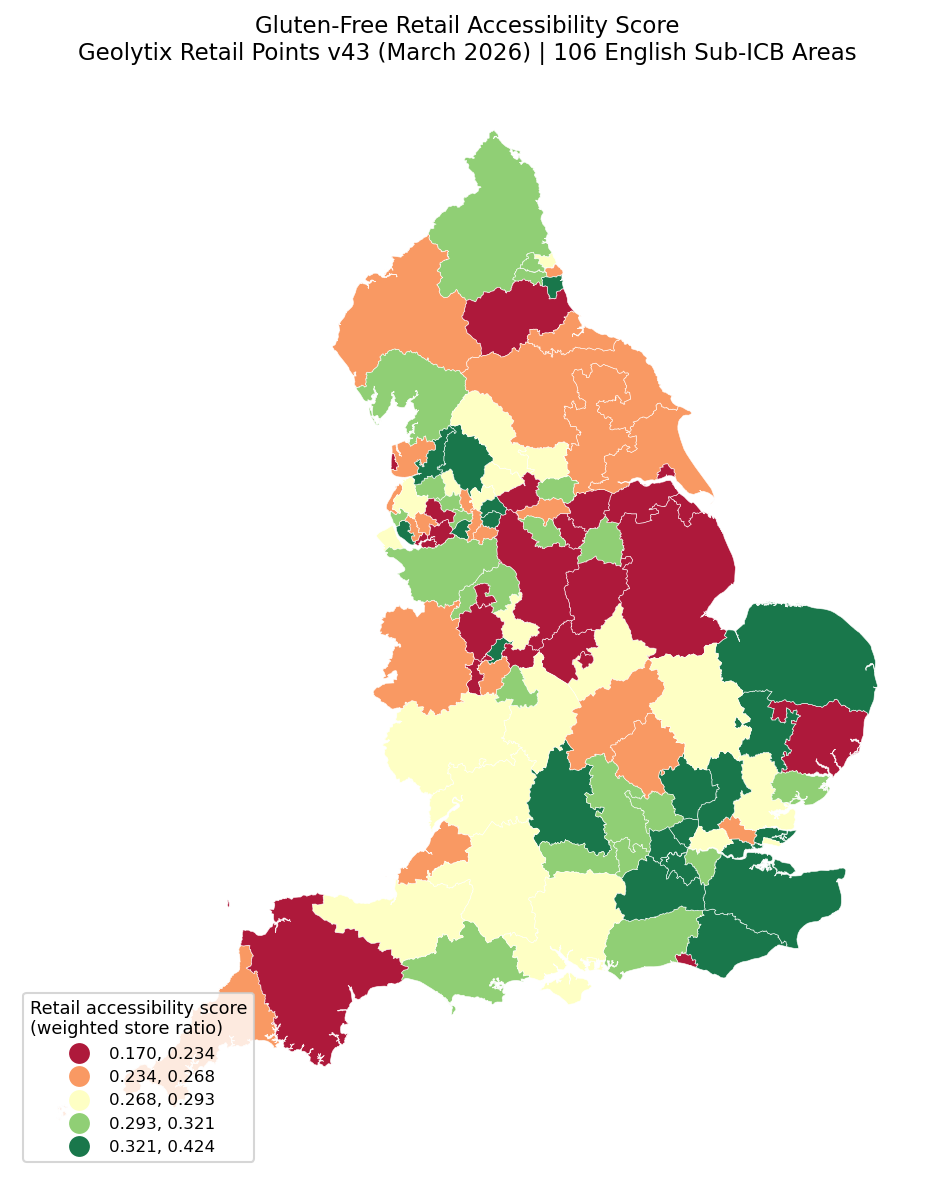

Saved MAP_01b.


In [5]:
# ── MAP 2 — GF Retail Accessibility ───────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf.plot(column='retail_accessibility_score', ax=ax,
         cmap='RdYlGn', scheme='quantiles', k=5,
         legend=True,
         legend_kwds={
             'title': 'Retail accessibility score\n(weighted store ratio)',
             'loc': 'lower left', 'fontsize': 8, 'title_fontsize': 8.5,
             'fmt': '{:.3f}',
         },
         edgecolor='white', linewidth=0.3, alpha=0.9)

ax.set_title('Gluten-Free Retail Accessibility Score\n'
             'Geolytix Retail Points v43 (March 2026) | 106 English Sub-ICB Areas',
             fontsize=11, pad=10)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_01b_retail.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_01b.")

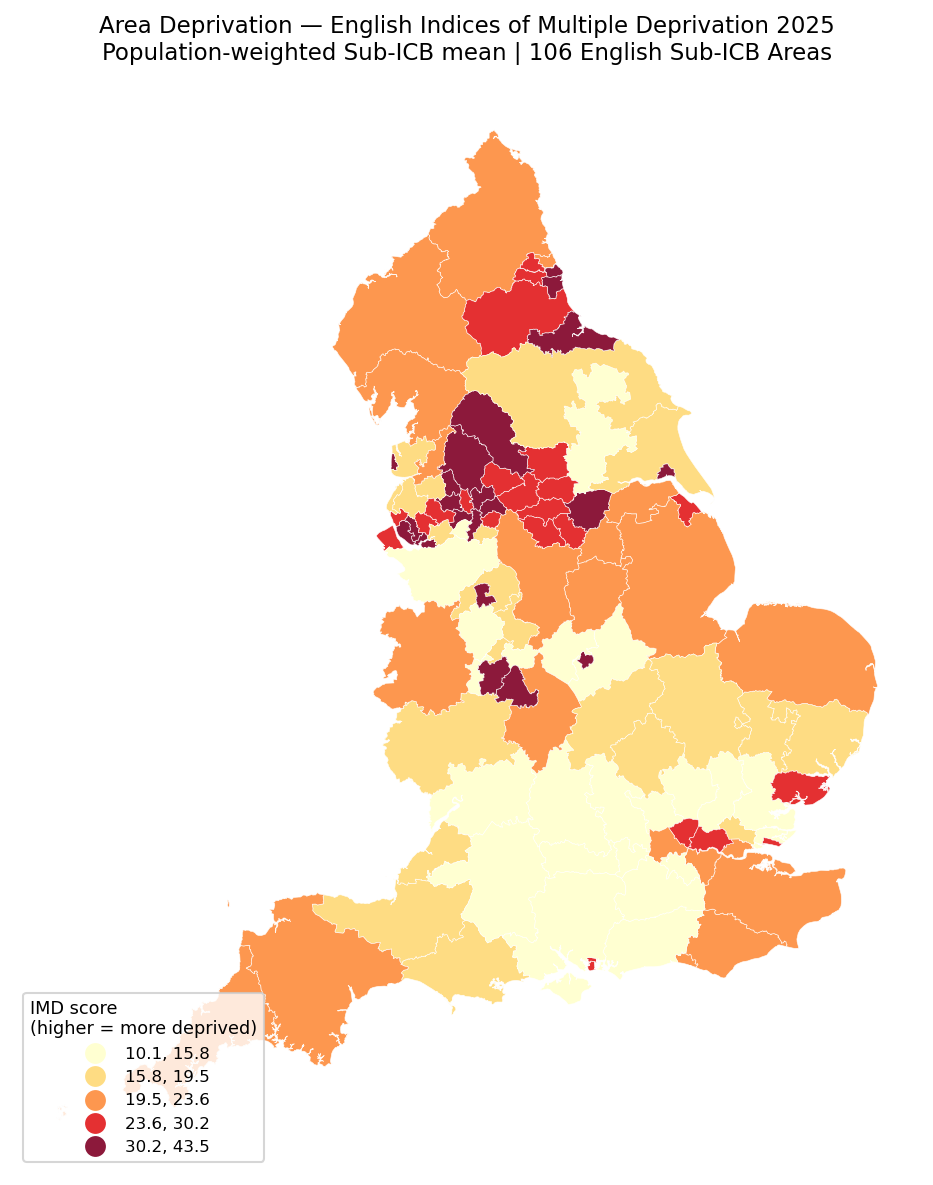

Saved MAP_01c.


In [6]:
# ── MAP 3 — Area Deprivation ───────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf.plot(column='imd_score_weighted', ax=ax,
         cmap='YlOrRd', scheme='quantiles', k=5,
         legend=True,
         legend_kwds={
             'title': 'IMD score\n(higher = more deprived)',
             'loc': 'lower left', 'fontsize': 8, 'title_fontsize': 8.5,
             'fmt': '{:.1f}',
         },
         edgecolor='white', linewidth=0.3, alpha=0.9)

ax.set_title('Area Deprivation — English Indices of Multiple Deprivation 2025\n'
             'Population-weighted Sub-ICB mean | 106 English Sub-ICB Areas',
             fontsize=11, pad=10)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_01c_imd.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_01c.")

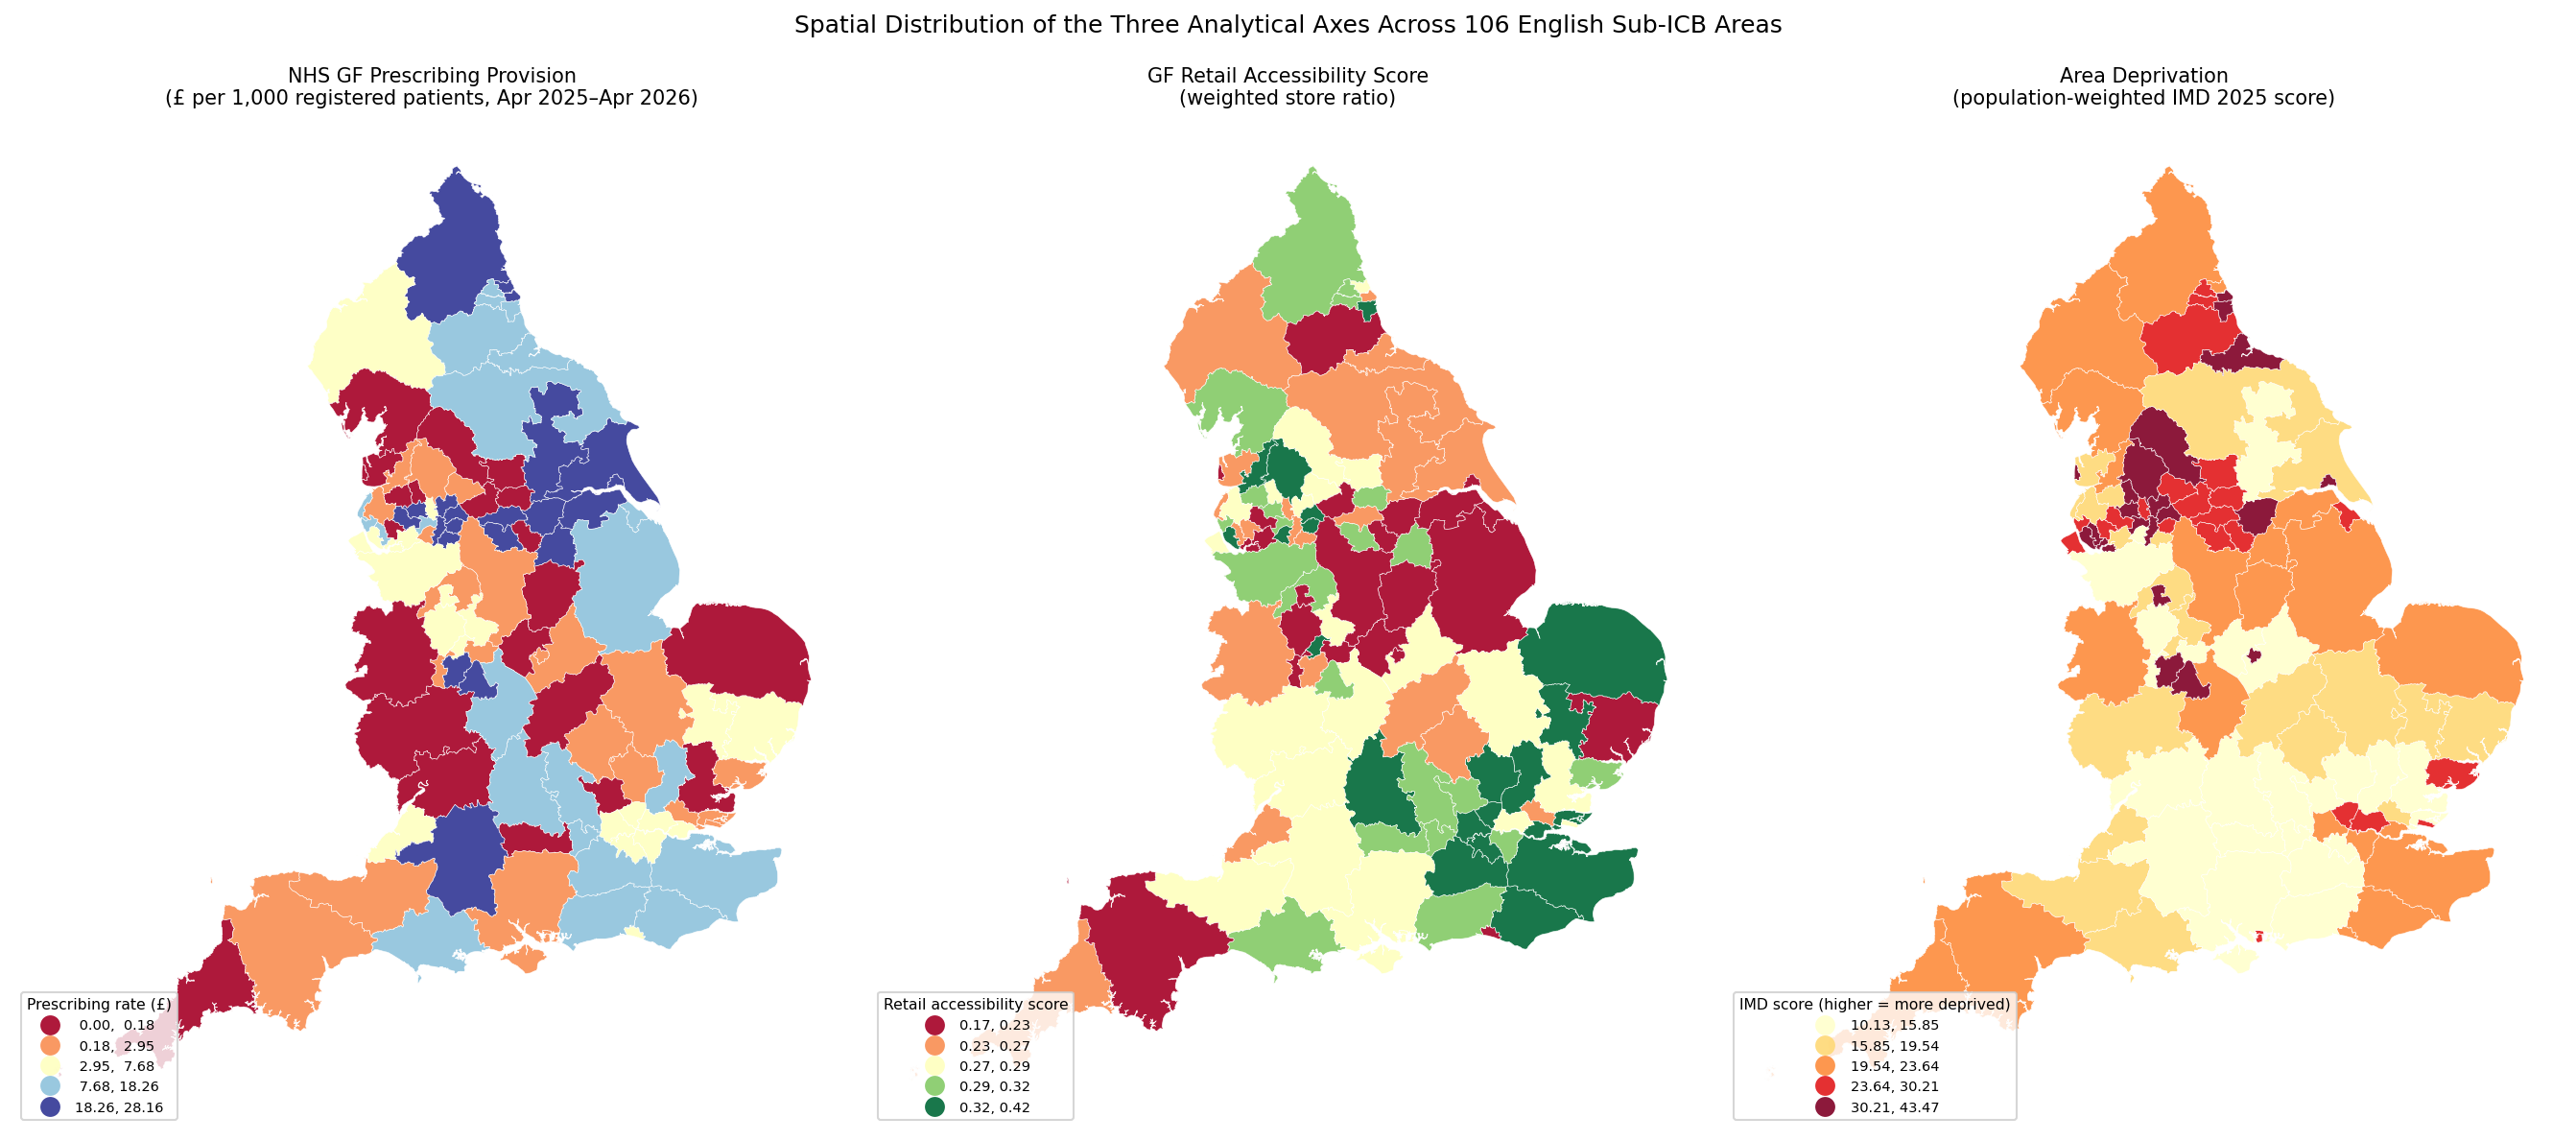

Saved MAP_01.


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 3 — THREE AXIS CHOROPLETH MAPS
# One map per analytical axis, consistent style
# ═══════════════════════════════════════════════════════════════════════════

def choropleth_map(ax, gdf, column, cmap, title, cbar_label,
                   scheme='quantiles', k=5, legend=True):
    """
    Clean choropleth map with quantile classification.
    """
    gdf.plot(column=column, ax=ax, cmap=cmap,
             scheme=scheme, k=k,
             legend=legend,
             legend_kwds={
                 'title': cbar_label,
                 'loc': 'lower left',
                 'fontsize': 7,
                 'title_fontsize': 7.5,
                 'fmt': '{:.2f}',
             },
             edgecolor='white', linewidth=0.3, alpha=0.9)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_axis_off()

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Map 1 — NHS GF Prescribing Rate
choropleth_map(
    axes[0], gdf, 'prescribing_rate_recent',
    cmap='RdYlBu',
    title='NHS GF Prescribing Provision\n(£ per 1,000 registered patients, Apr 2025–Apr 2026)',
    cbar_label='Prescribing rate (£)')

# Map 2 — Retail Accessibility
choropleth_map(
    axes[1], gdf, 'retail_accessibility_score',
    cmap='RdYlGn',
    title='GF Retail Accessibility Score\n(weighted store ratio)',
    cbar_label='Retail accessibility score')

# Map 3 — Area Deprivation
choropleth_map(
    axes[2], gdf, 'imd_score_weighted',
    cmap='YlOrRd',
    title='Area Deprivation\n(population-weighted IMD 2025 score)',
    cbar_label='IMD score (higher = more deprived)')

plt.suptitle(
    'Spatial Distribution of the Three Analytical Axes Across 106 English Sub-ICB Areas',
    fontsize=12, fontweight='normal', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_01_three_axes.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_01.")

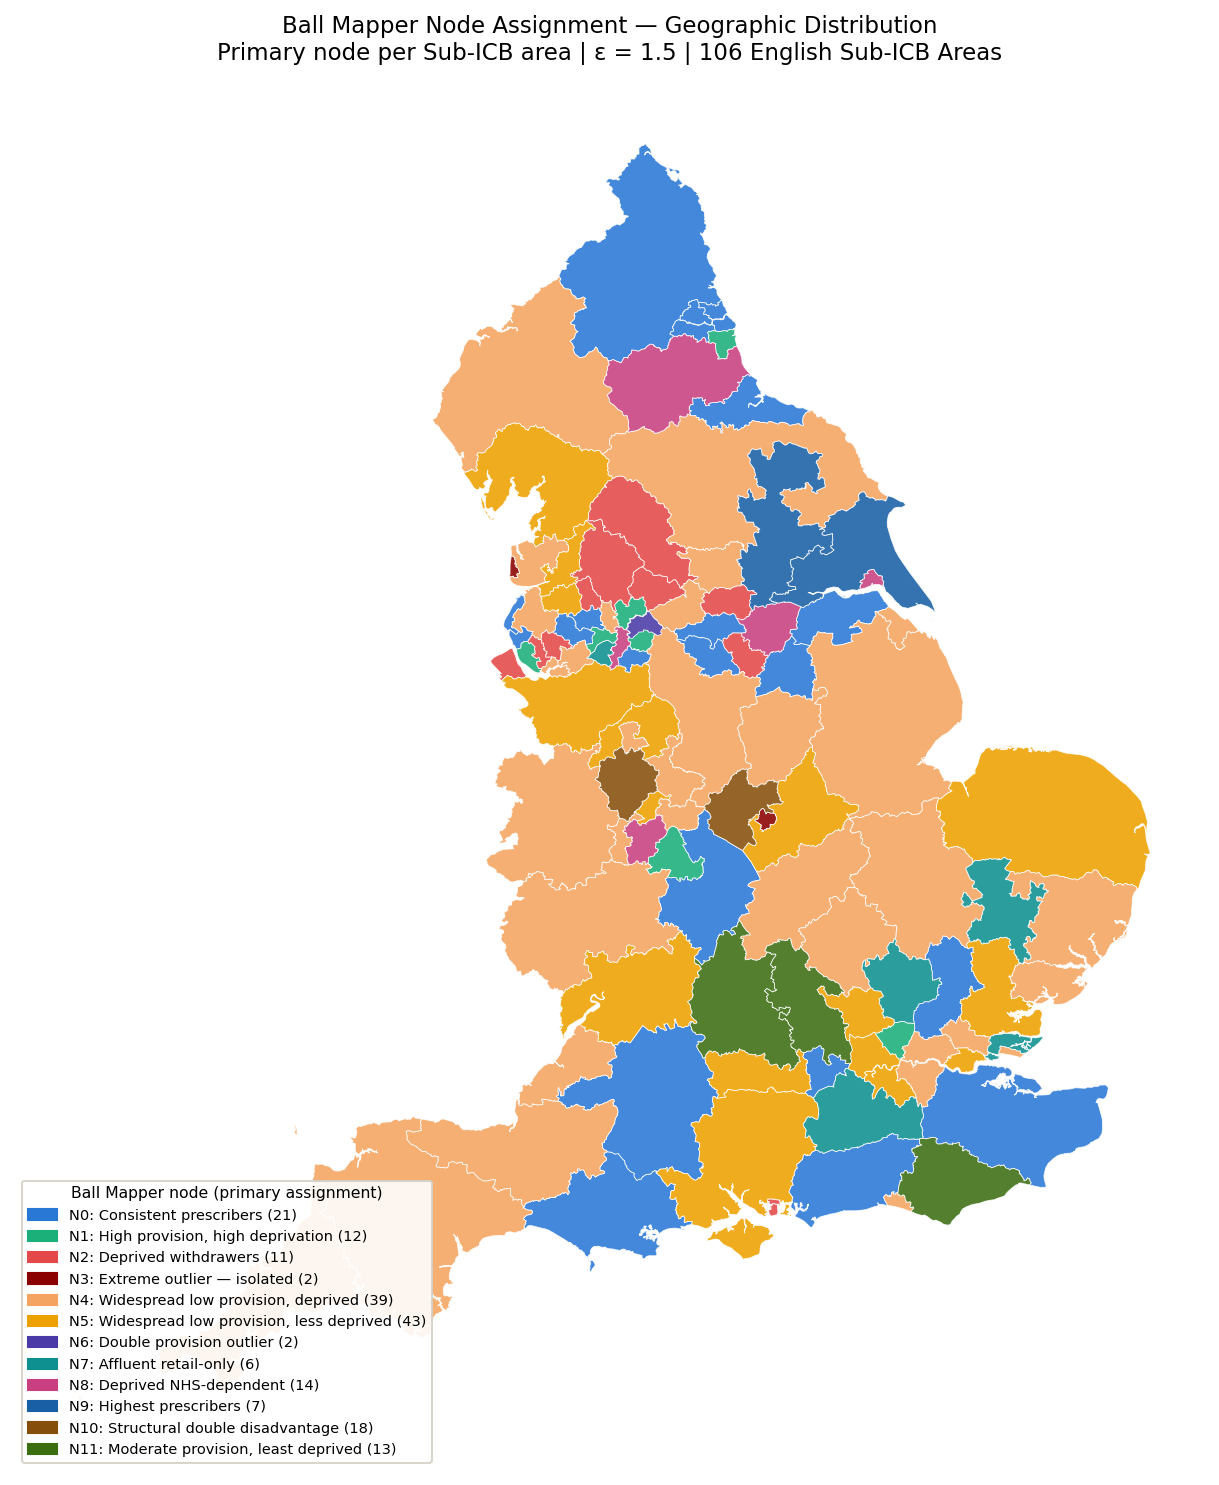

Saved MAP_02.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4 — BALL MAPPER NODE ASSIGNMENT MAP
# Geographic distribution of Ball Mapper node membership
# Primary node assignment (first node each area belongs to)
# ═══════════════════════════════════════════════════════════════════════════

# Assign primary node to gdf
gdf = gdf.merge(df[['org_id', 'bm_node', 'bm_label']],
                on='org_id', how='left',
                suffixes=('', '_new'))

# Use _new columns if bm_node already exists from Cell 2
if 'bm_node_new' in gdf.columns:
    gdf['bm_node']  = gdf['bm_node_new']
    gdf['bm_label'] = gdf['bm_label_new']
    gdf = gdf.drop(columns=['bm_node_new', 'bm_label_new'])

# Node colours — consistent with Ball Mapper notebook
node_colors = {
    0:  '#2a78d6',   # Consistent prescribers — blue
    1:  '#1baf7a',   # High provision, high deprivation — green
    2:  '#e34948',   # Deprived withdrawers — red
    3:  '#8b0000',   # Extreme outlier — dark red
    4:  '#f4a460',   # Widespread low provision (deprived) — sandy
    5:  '#eda100',   # Widespread low provision (less deprived) — amber
    6:  '#4a3aa7',   # Double provision outlier — purple
    7:  '#0f9090',   # Affluent retail-only — teal
    8:  '#c94080',   # Deprived NHS-dependent — pink
    9:  '#185FA5',   # Highest prescribers — dark blue
    10: '#854F0B',   # Structural double disadvantage — brown
    11: '#3B6D11',   # Moderate provision, least deprived — dark green
}

node_labels_map = {
    0:  'N0: Consistent prescribers (21)',
    1:  'N1: High provision, high deprivation (12)',
    2:  'N2: Deprived withdrawers (11)',
    3:  'N3: Extreme outlier — isolated (2)',
    4:  'N4: Widespread low provision, deprived (39)',
    5:  'N5: Widespread low provision, less deprived (43)',
    6:  'N6: Double provision outlier (2)',
    7:  'N7: Affluent retail-only (6)',
    8:  'N8: Deprived NHS-dependent (14)',
    9:  'N9: Highest prescribers (7)',
    10: 'N10: Structural double disadvantage (18)',
    11: 'N11: Moderate provision, least deprived (13)',
}

# Map node colour to each area
gdf['node_color'] = gdf['bm_node'].map(node_colors)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

for nid, color in node_colors.items():
    subset = gdf[gdf['bm_node'] == nid]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='white',
                    linewidth=0.4, alpha=0.88)

# Legend
handles = [
    mpatches.Patch(color=node_colors[nid], label=node_labels_map[nid])
    for nid in sorted(node_colors.keys())
    if len(gdf[gdf['bm_node'] == nid]) > 0
]
ax.legend(handles=handles, loc='lower left', fontsize=7,
          title='Ball Mapper node (primary assignment)',
          title_fontsize=7.5,
          framealpha=0.9, edgecolor='#d3d1c7')

ax.set_title(
    'Ball Mapper Node Assignment — Geographic Distribution\n'
    'Primary node per Sub-ICB area | ε = 1.5 | 106 English Sub-ICB Areas',
    fontsize=11, pad=10)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_02_ballmapper_nodes.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_02.")

Computing LISA for prescribing provision...
Computing LISA for retail accessibility...

LISA Results — Prescribing Provision:
Not significant    84
High-High          19
Low-Low             3

LISA Results — Retail Accessibility:
Not significant    77
High-High          16
Low-Low            13


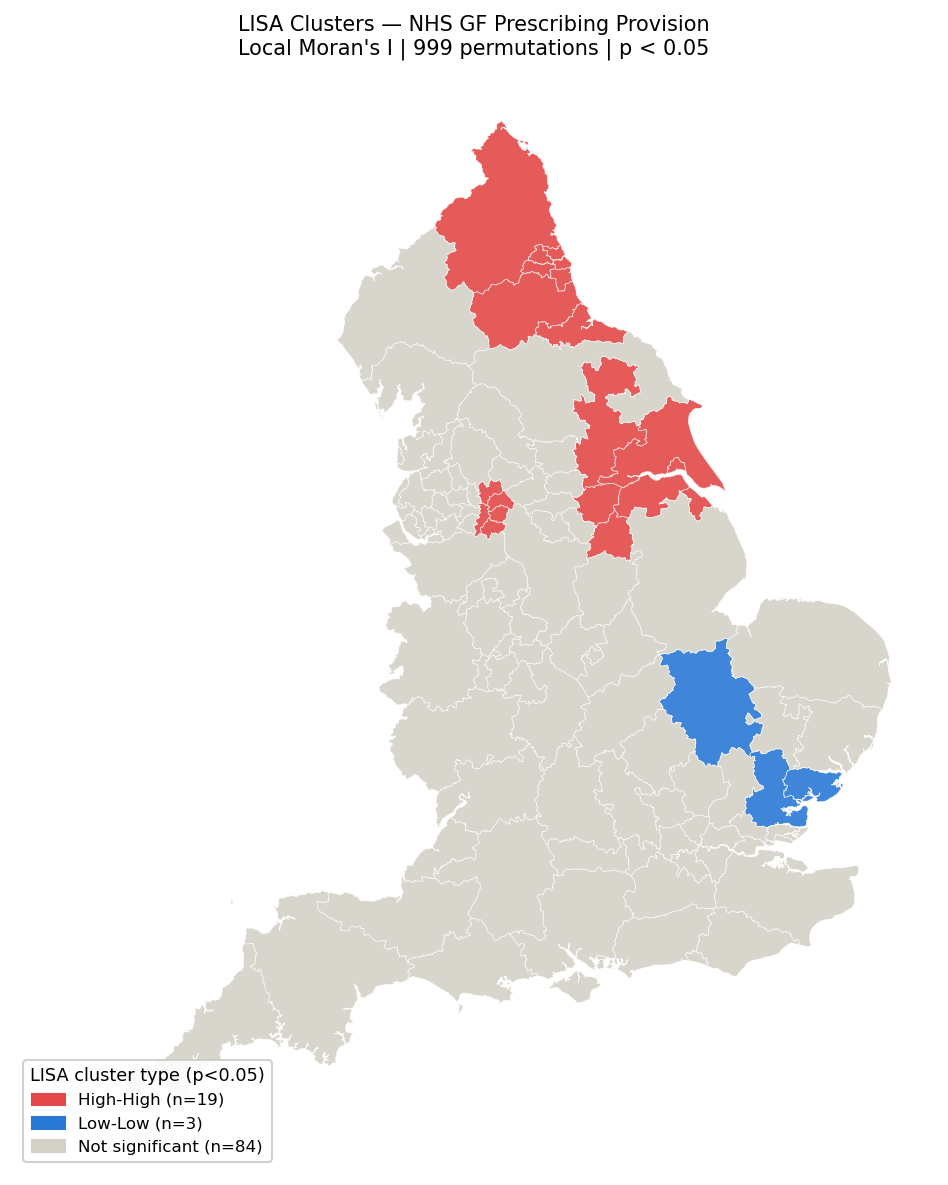

Saved MAP_03a.


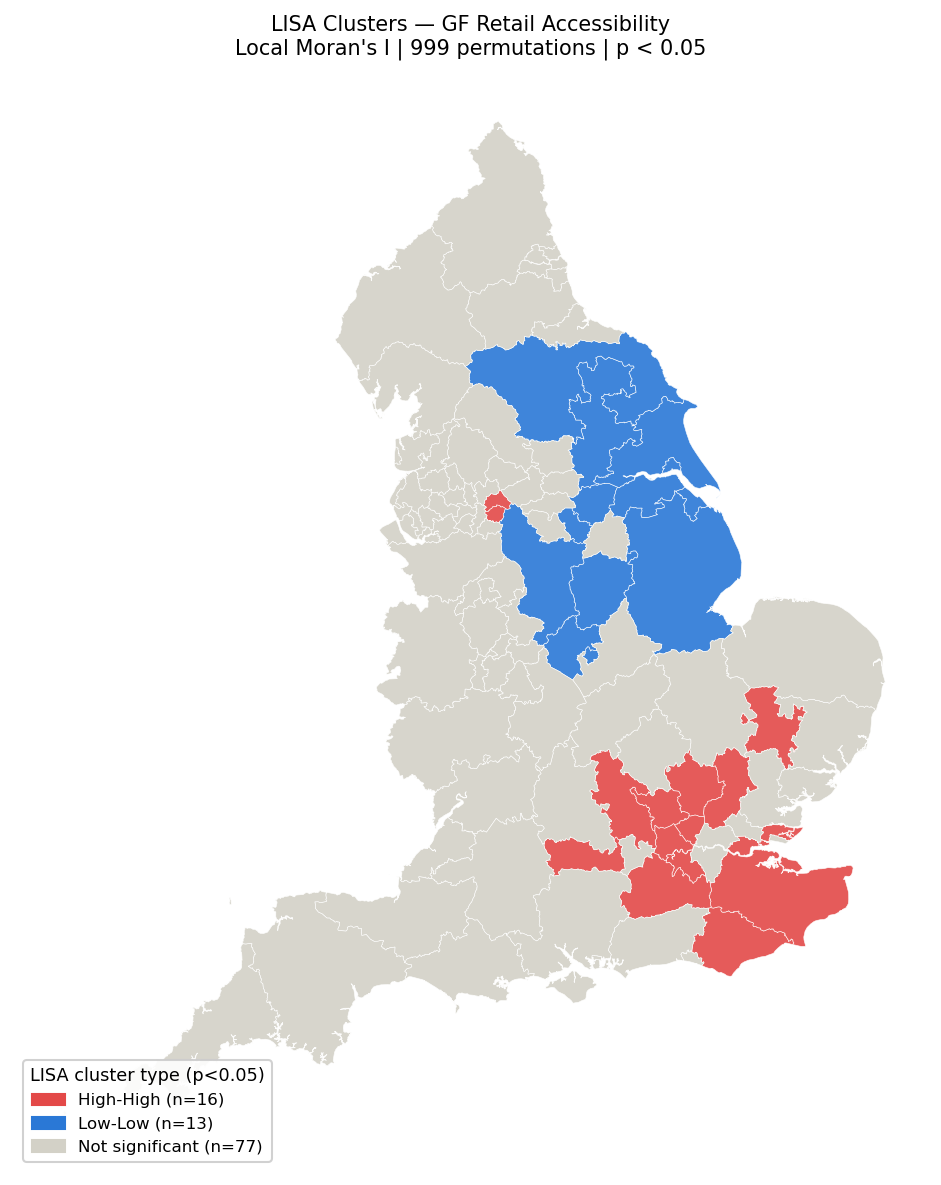

Saved MAP_03b.


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — LISA LOCAL SPATIAL AUTOCORRELATION
# Local Indicators of Spatial Association for prescribing and retail
# Identifies statistically significant local clusters and outliers
# Following Anselin (1995)
# ═══════════════════════════════════════════════════════════════════════════

from scipy.spatial.distance import cdist

# ── Spatial weights matrix (inverse distance) ─────────────────────────────
coords      = gdf[['centroid_lon', 'centroid_lat']].values
dist_matrix = cdist(coords, coords, metric='euclidean')
np.fill_diagonal(dist_matrix, np.inf)
W           = 1 / dist_matrix
np.fill_diagonal(W, 0)
W_std       = W / W.sum(axis=1, keepdims=True)

def local_morans_i(values, W, n_perm=999):
    """
    Local Moran's I (LISA) for each observation.
    Returns local I, z-score, p-value, and cluster type.
    Following Anselin (1995).
    """
    n    = len(values)
    z    = (values - values.mean()) / values.std()
    Ii   = z * (W_std @ z)
    
    # Permutation test for each location
    np.random.seed(42)
    Ii_perm = np.zeros((n_perm, n))
    for p in range(n_perm):
        z_perm     = np.random.permutation(z)
        Ii_perm[p] = z_perm * (W_std @ z_perm)
    
    p_values = np.mean(Ii_perm >= Ii, axis=0)
    z_scores = (Ii - Ii_perm.mean(axis=0)) / Ii_perm.std(axis=0)
    
    # Cluster type classification
    Wz       = W_std @ z
    sig      = p_values < 0.05
    cluster  = np.full(n, 'Not significant', dtype=object)
    cluster[(z > 0) & (Wz > 0) & sig] = 'High-High'
    cluster[(z < 0) & (Wz < 0) & sig] = 'Low-Low'
    cluster[(z > 0) & (Wz < 0) & sig] = 'High-Low'
    cluster[(z < 0) & (Wz > 0) & sig] = 'Low-High'
    
    return Ii, z_scores, p_values, cluster

# ── Compute LISA for prescribing and retail ────────────────────────────────
print("Computing LISA for prescribing provision...")
presc_vals = gdf['prescribing_rate_recent'].values
Ii_p, z_p, pv_p, cl_p = local_morans_i(presc_vals, W_std)
gdf['lisa_presc_cluster'] = cl_p
gdf['lisa_presc_pvalue']  = pv_p

print("Computing LISA for retail accessibility...")
retail_vals = gdf['retail_accessibility_score'].values
Ii_r, z_r, pv_r, cl_r = local_morans_i(retail_vals, W_std)
gdf['lisa_retail_cluster'] = cl_r
gdf['lisa_retail_pvalue']  = pv_r

# ── Print summary ──────────────────────────────────────────────────────────
print("\nLISA Results — Prescribing Provision:")
print(pd.Series(cl_p).value_counts().to_string())

print("\nLISA Results — Retail Accessibility:")
print(pd.Series(cl_r).value_counts().to_string())

# ── LISA cluster maps ──────────────────────────────────────────────────────
lisa_colors = {
    'High-High':       '#e34948',
    'Low-Low':         '#2a78d6',
    'High-Low':        '#eda100',
    'Low-High':        '#1baf7a',
    'Not significant': '#d3d1c7',
}

def lisa_map(ax, gdf, cluster_col, title):
    for cluster_type, color in lisa_colors.items():
        subset = gdf[gdf[cluster_col] == cluster_type]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color,
                       edgecolor='white', linewidth=0.3, alpha=0.9)
    handles = [
        mpatches.Patch(color=c, label=f'{ct} (n={len(gdf[gdf[cluster_col]==ct])})')
        for ct, c in lisa_colors.items()
        if len(gdf[gdf[cluster_col] == ct]) > 0
    ]
    ax.legend(handles=handles, loc='lower left', fontsize=8,
              title='LISA cluster type (p<0.05)',
              title_fontsize=8.5, framealpha=0.9)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_axis_off()

# Map 1 — Prescribing LISA
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
lisa_map(ax, gdf, 'lisa_presc_cluster',
         'LISA Clusters — NHS GF Prescribing Provision\n'
         'Local Moran\'s I | 999 permutations | p < 0.05')
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_03a_lisa_prescribing.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_03a.")

# Map 2 — Retail LISA
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
lisa_map(ax, gdf, 'lisa_retail_cluster',
         'LISA Clusters — GF Retail Accessibility\n'
         'Local Moran\'s I | 999 permutations | p < 0.05')
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_03b_lisa_retail.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_03b.")

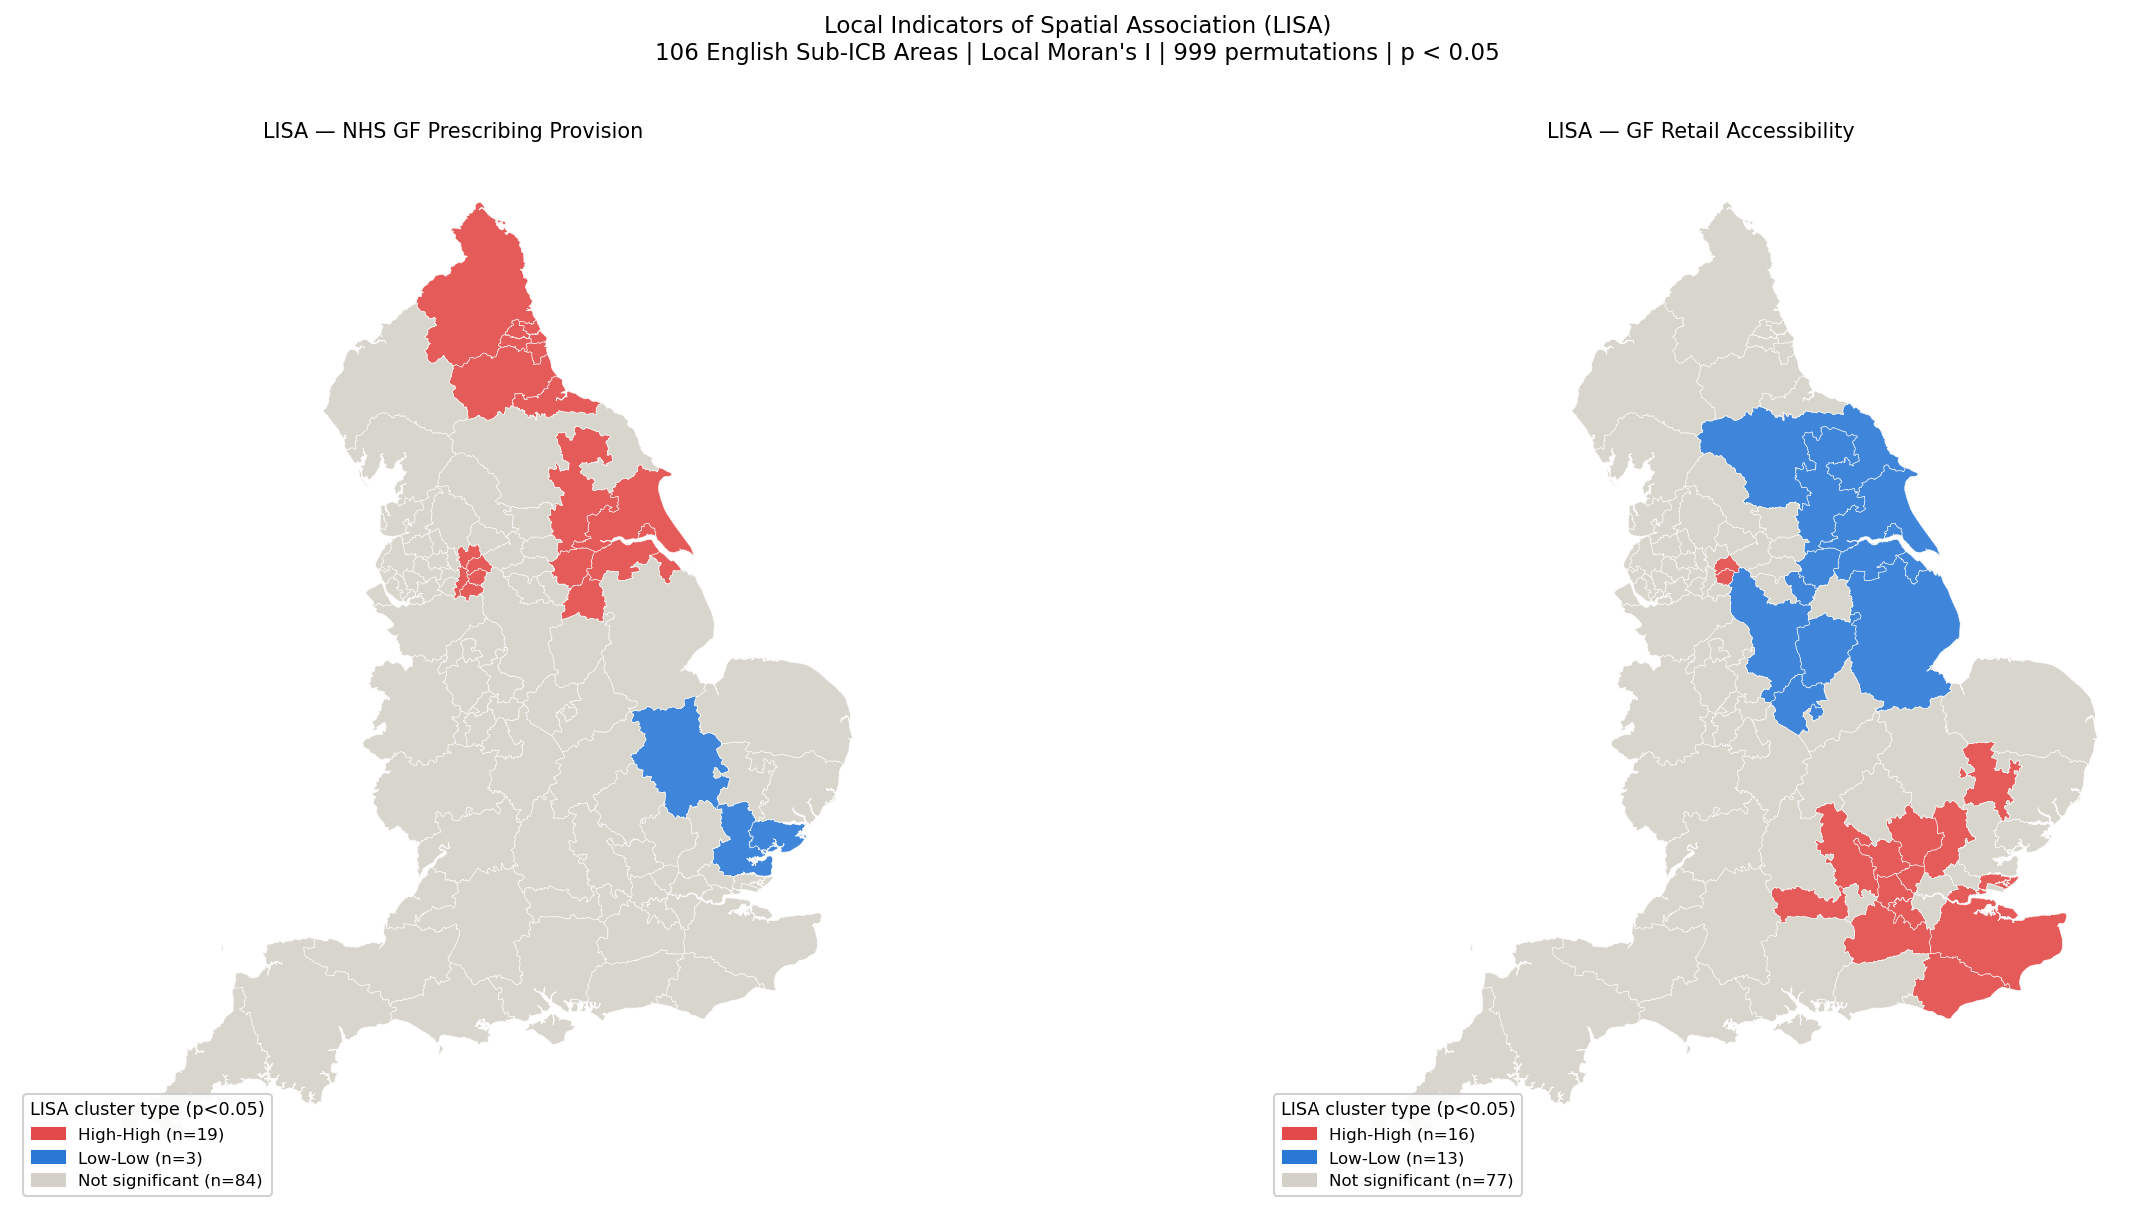

Saved MAP_03_lisa_combined.
Saved LISA_results.csv
Updated analytical_dataset_final.csv

Figures saved in this notebook:
  outputs/figures/MAP_01a_prescribing.png
  outputs/figures/MAP_01b_retail.png
  outputs/figures/MAP_01c_imd.png
  outputs/figures/MAP_02_ballmapper_nodes.png
  outputs/figures/MAP_03a_lisa_prescribing.png
  outputs/figures/MAP_03b_lisa_retail.png
  outputs/figures/MAP_03_lisa_combined.png

Tables saved:
  outputs/tables/LISA_results.csv

LISA summary:
  Prescribing HH: 19 | LL: 3 | NS: 84
  Retail HH: 16 | LL: 13 | NS: 77

Notebook 05 complete. Ready to commit.


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 6 — COMBINED LISA MAP AND FINAL SAVE
# ═══════════════════════════════════════════════════════════════════════════

# Combined side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

lisa_map(axes[0], gdf, 'lisa_presc_cluster',
         'LISA — NHS GF Prescribing Provision')
lisa_map(axes[1], gdf, 'lisa_retail_cluster',
         'LISA — GF Retail Accessibility')

plt.suptitle(
    'Local Indicators of Spatial Association (LISA)\n'
    '106 English Sub-ICB Areas | Local Moran\'s I | '
    '999 permutations | p < 0.05',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_03_lisa_combined.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_03_lisa_combined.")

# Save LISA results
lisa_results = gdf[['org_id', 'org_name',
                     'lisa_presc_cluster', 'lisa_presc_pvalue',
                     'lisa_retail_cluster', 'lisa_retail_pvalue']].copy()
lisa_results.to_csv(f'{TAB_PATH}/LISA_results.csv', index=False)
print("Saved LISA_results.csv")

# Update analytical dataset
df_updated = df.merge(
    lisa_results[['org_id', 'lisa_presc_cluster', 'lisa_retail_cluster']],
    on='org_id', how='left')
df_updated.to_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv',
    index=False)
print("Updated analytical_dataset_final.csv")

# Summary
print("\nFigures saved in this notebook:")
for f in ['MAP_01a_prescribing.png', 'MAP_01b_retail.png',
          'MAP_01c_imd.png', 'MAP_02_ballmapper_nodes.png',
          'MAP_03a_lisa_prescribing.png', 'MAP_03b_lisa_retail.png',
          'MAP_03_lisa_combined.png']:
    print(f"  outputs/figures/{f}")

print("\nTables saved:")
print("  outputs/tables/LISA_results.csv")

print(f"\nLISA summary:")
print(f"  Prescribing HH: {(gdf['lisa_presc_cluster']=='High-High').sum()} | "
      f"LL: {(gdf['lisa_presc_cluster']=='Low-Low').sum()} | "
      f"NS: {(gdf['lisa_presc_cluster']=='Not significant').sum()}")
print(f"  Retail HH: {(gdf['lisa_retail_cluster']=='High-High').sum()} | "
      f"LL: {(gdf['lisa_retail_cluster']=='Low-Low').sum()} | "
      f"NS: {(gdf['lisa_retail_cluster']=='Not significant').sum()}")

print("\nNotebook 05 complete. Ready to commit.")